# Detección de Anomalías en Transacciones con Tarjeta de Crédito
**Enfoque:** Aprendizaje no supervisado.

## 1. Introducción y Planteamiento del Problema

El fraude con tarjeta de crédito es un problema de alta relevancia en sistemas financieros: ocurre con baja frecuencia pero con consecuencias económicas significativas. El objetivo de este proyecto es construir un sistema capaz de detectar transacciones fraudulentas de forma automática.

### Tipo de aprendizaje

El enfoque adoptado es no supervisado. Los modelos se entrenan exclusivamente con transacciones legítimas y aprenden a representar el comportamiento normal. Una transacción se considera sospechosa cuando se desvía significativamente de ese comportamiento aprendido.

### Modelos evaluados

- **Isolation Forest:** aislamiento aleatorio en árboles (S5).
- **Local Outlier Factor (k=20):** anomalías por densidad local (S6).
- **Autoencoder:** error de reconstrucción sobre transacciones normales (S7).

### Criterio de evaluación y decisión

- Métricas: precision, recall, F1, AUC-ROC y PR-AUC.
- El umbral lo calibramos en validación y las métricas finales de la comparativa se reportan en test.
- Vamos a priorizar el f1 que es un balance entre precision y recall, igual que en las secciones 5 a 7.
- Modelo final los escogemos en la sección 8.

Las etiquetas de clase disponibles en el dataset `is_fraud` se reservan exclusivamente para evaluar el desempeño de los modelos, no para entrenarlos.

### Variables

- **Entrada:** características de la transacción derivadas del dataset. Las variables exactas que ingresan al modelo se definen en la sección 4, tras el análisis exploratorio y el preprocesamiento.
- **Salida (por modelo):** nivel de anomalía (un rango entre 0 y 1) y una etiqueta binaria (Normal / Anómalo).

## 2. Descripción del Dataset

El dataset utilizado es **Fraud_detection**, publicado en Kaggle por reemkasaab. Fue generado mediante la herramienta Sparkov Data Generation creada por Brandon Harris, que simula transacciones con tarjeta de crédito a partir de perfiles de comportamiento definidos por parámetros como frecuencia de transacciones, distribución de montos por categoría y patrones temporales.

El dataset cubre el período enero 2019 - diciembre 2020 e incluye transacciones simuladas de 1,000 clientes con 800 comerciantes distintos.

**Fuente:** https://www.kaggle.com/datasets/reemkasaab/fraud-detection  
**Licencia:** No especificada

Las dimensiones, distribución de clases, tipos de datos y valores nulos se verifican a continuación directamente sobre el archivo. El archivo cargado presenta 23 columnas: 22 variables del dataset más `Unnamed: 0`, que es el índice numérico del CSV original y no representa información del dominio.

In [1]:
from src.preprocessing import load_data, describe_dataset

df = load_data("data.csv")
describe_dataset(df)

Dimensiones: 1,852,394 filas × 23 columnas

Distribución de clases:
is_fraud
Normal    1842743
Fraude       9651
Name: count, dtype: int64

Porcentaje de fraude: 0.52%

Tipos de datos:
Unnamed: 0                 int64
trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

Valores nulos:
Ninguno

Primeras filas:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0



Resumen estadístico (variables numéricas):


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,"1,852,394","537,193.44","366,910.96",0.00,"231,549.00","463,098.00","833,575.75","1,296,674.00"
cc_num,"1,852,394","417,386,038,393,710,400.00","1,309,115,265,318,735,104.00","60,416,207,185.00","180,042,946,491,150.00","3,521,417,320,836,166.00","4,642,255,475,285,942.00","4,992,346,398,065,154,048.00"
amt,"1,852,394",70.06,159.25,1.00,9.64,47.45,83.10,"28,948.90"
zip,"1,852,394","48,813.26","26,881.85","1,257.00","26,237.00","48,174.00","72,042.00","99,921.00"
lat,"1,852,394",38.54,5.07,20.03,34.67,39.35,41.94,66.69
long,"1,852,394",-90.23,13.75,-165.67,-96.80,-87.48,-80.16,-67.95
city_pop,"1,852,394","88,643.67","301,487.62",23.00,741.00,"2,443.00","20,328.00","2,906,700.00"
unix_time,"1,852,394","1,358,674,218.83","18,195,081.39","1,325,376,018.00","1,343,016,823.75","1,357,089,331.00","1,374,581,485.25","1,388,534,374.00"
merch_lat,"1,852,394",38.54,5.11,19.03,34.74,39.37,41.96,67.51
merch_long,"1,852,394",-90.23,13.76,-166.67,-96.90,-87.44,-80.25,-66.95


### Limitaciones del dataset

- **Naturaleza sintética:** generado por simulación, por lo que puede no cubrir todos los patrones reales de fraude.
- **Licencia no especificada:** limita su uso fuera del ámbito educativo y analítico.
- **Período acotado:** dos años de datos pueden introducir sesgo temporal si los patrones de fraude han cambiado.
- **Sin descripción oficial de columnas:** el dataset no incluye un diccionario de datos formal.

## 3. Análisis Exploratorio (EDA)

Antes de modelar, se exploran los patrones del dataset para entender la naturaleza de los datos y fundamentar las decisiones de preprocesamiento. El EDA busca responder cinco preguntas clave:

1. ¿Qué tan desbalanceado está el dataset?
2. ¿Los montos de transacciones fraudulentas difieren de las normales?
3. ¿Hay categorías de comercio con mayor incidencia de fraude?
4. ¿El fraude sigue patrones temporales (hora del día, día de la semana)?
5. ¿Existe diferencia en la tasa de fraude entre géneros?

In [2]:
from src.eda import (
    plot_class_distribution, plot_amount_by_class, plot_fraud_by_category,
    plot_time_patterns, plot_fraud_by_gender
)

Distribución de clases:
  Normal: 1,842,743 (99.48%)
  Fraude: 9,651 (0.52%)


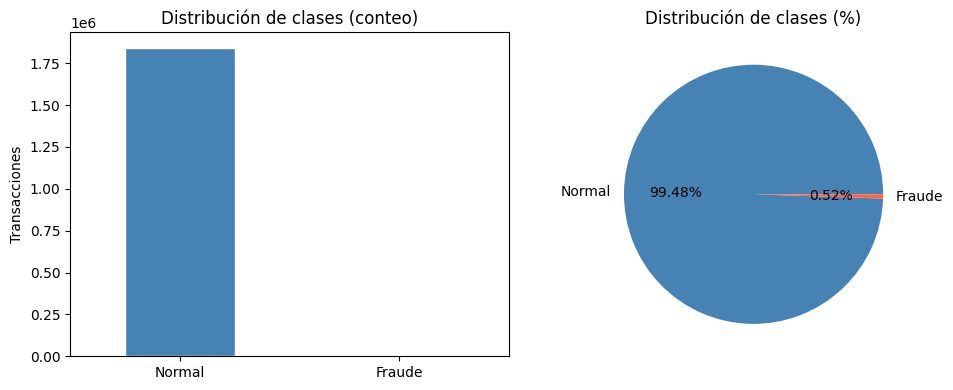

In [3]:
# 1. ¿Qué tan desbalanceado está el dataset?
plot_class_distribution(df)

El dataset está muy desbalanceado. De casi dos millones de transacciones, solo 9 651 son fraude. En el gráfico de barras la barra de fraude es prácticamente invisible, y en el otro gráfico circular vemos lo mismo, es casi todo normal. Eso nos dice que para este proyecto no nos sirve mirar solo la métrica de accuracy porque un modelo que siempre diga que es normal tendría un 99,48%. Que haya fraude en este dataset en raro, también por eso vamos a utilizar modelos de detección de anomalías.

Estadísticas de monto por clase:
              count        mean         std   min      25%     50%      75%       max
is_fraud                                                                             
Normal    1842743.0   67.651278  153.548108  1.00    9.610   47.24   82.560  28948.90
Fraude       9651.0  530.661412  391.028873  1.06  240.075  390.00  902.365   1376.04


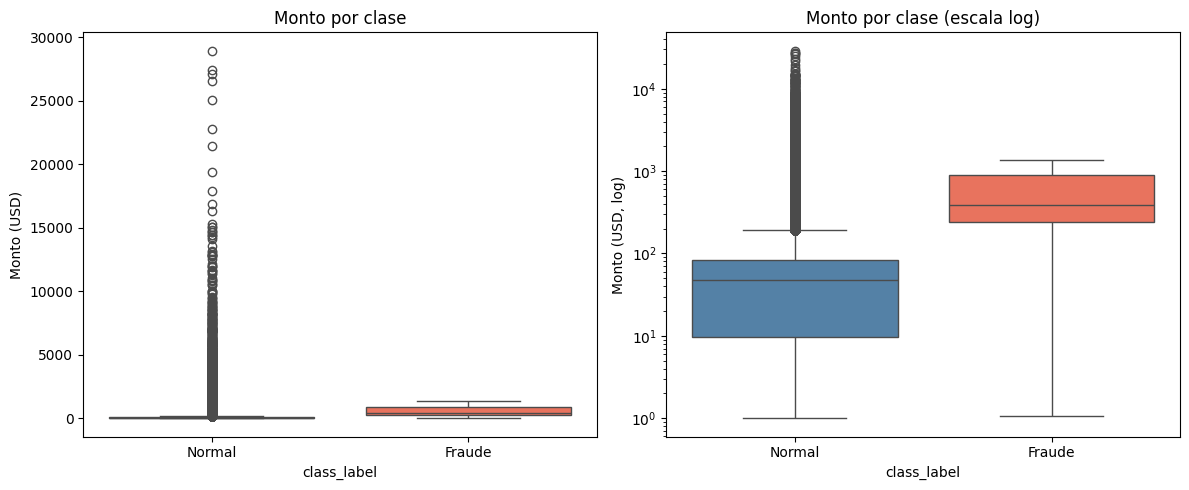

In [4]:
# 2. ¿Los montos de transacciones fraudulentas difieren de las normales?
plot_amount_by_class(df)

En el gráfico de la izquierda, con escala de dinero normal, la caja de fraude apenas se ve, y la normal no. Lo que más se ve son los montos altos de las transacciones normales porque tienen montos mucho mas altos que las fraudulentas. El gráfico de la derecha en escala log es para que se entienda mejor todo.

En la de la derecha vemos que la mediana de normales es 47,24 dólares y la de fraude es 390, o sea bastante más. Además, el 75% de las normales queda por debajo de 82,56 dólares, y eso que ni siquiera llega al 25% del fraude, que empieza alrededor de 240. Esto nos dice que muchas transacciones fraudulentas tienen montos mayores que la mayoría de las normales.

Otra cosa que notamos es que los montos más altos del dataset son de transacciones normales. El fraude no llega hasta ahí, sino hasta 1 376 dólares y la mayoría cae en un rango más limitado de entre unos 240 y 902. Entonces el monto sí aporta para detectar fraude y por eso lo vamos a usar en los modelos, junto con su versión en log.

Tasa de fraude por categoría (%):
category
shopping_net      1.59
misc_net          1.30
grocery_pos       1.26
shopping_pos      0.63
gas_transport     0.41
misc_pos          0.28
grocery_net       0.27
travel            0.27
personal_care     0.22
entertainment     0.22
kids_pets         0.19
food_dining       0.16
home              0.15
health_fitness    0.15


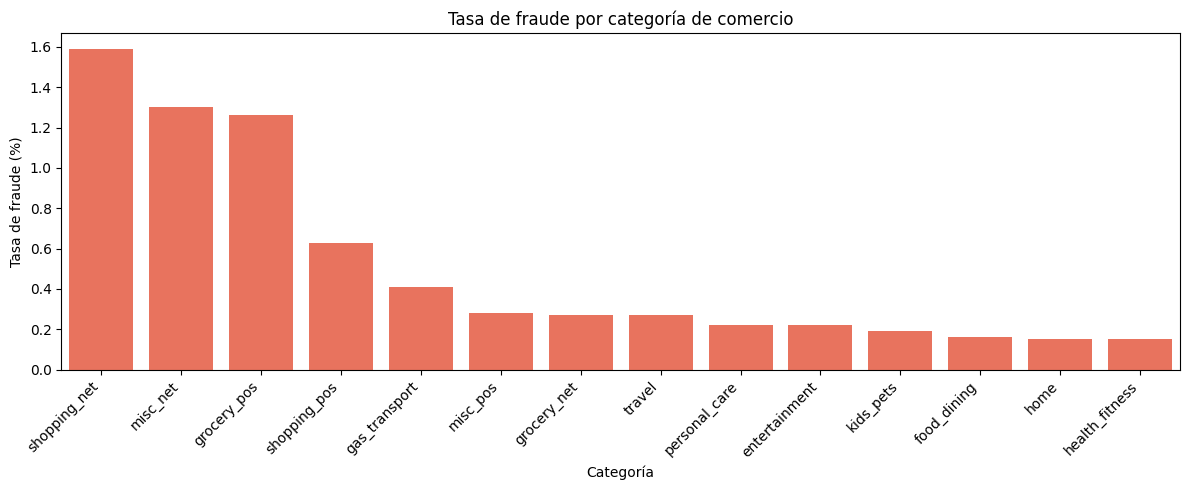

In [5]:
# 3. ¿Hay categorías de comercio con mayor incidencia de fraude?
plot_fraud_by_category(df)

En este gráfico vemos que la tasa de fraude no es la misma en todos los tipos de comercio. Las barras más altas están a la izquierda: shopping_net llega a 1,59%, le siguen misc_net con 1,30% y grocery_pos con 1,26%. Hacia la derecha las barras van bajando y al final home y health_fitness quedan en 0,15%.

Eso nos dice que el fraude sigue siendo raro en todas las categorías, pero la probabilidad cambia bastante según dónde se hizo la compra. Entre la categoría con más fraude y las que tienen menos hay mucha diferencia.

También notamos que dos de las tres categorías con más fraude son shopping_net y misc_net, lo cual tiene sentido porque son compras en línea, deberia ser más facil hacer fraude en internet. Por eso la categoría del comercio sí nos sirve como variable y la vamos a incluir en los modelos.

Tasa de fraude por hora:
hour
0     1.36
1     1.35
2     1.30
3     1.32
4     0.10
5     0.13
6     0.09
7     0.12
8     0.10
9     0.10
10    0.09
11    0.10
12    0.09
13    0.10
14    0.11
15    0.11
16    0.10
17    0.10
18    0.12
19    0.11
20    0.11
21    0.11
22    2.60
23    2.55

Tasa de fraude por día:
weekday
Lunes        0.40
Martes       0.47
Miércoles    0.61
Jueves       0.64
Viernes      0.64
Sábado       0.57
Domingo      0.46


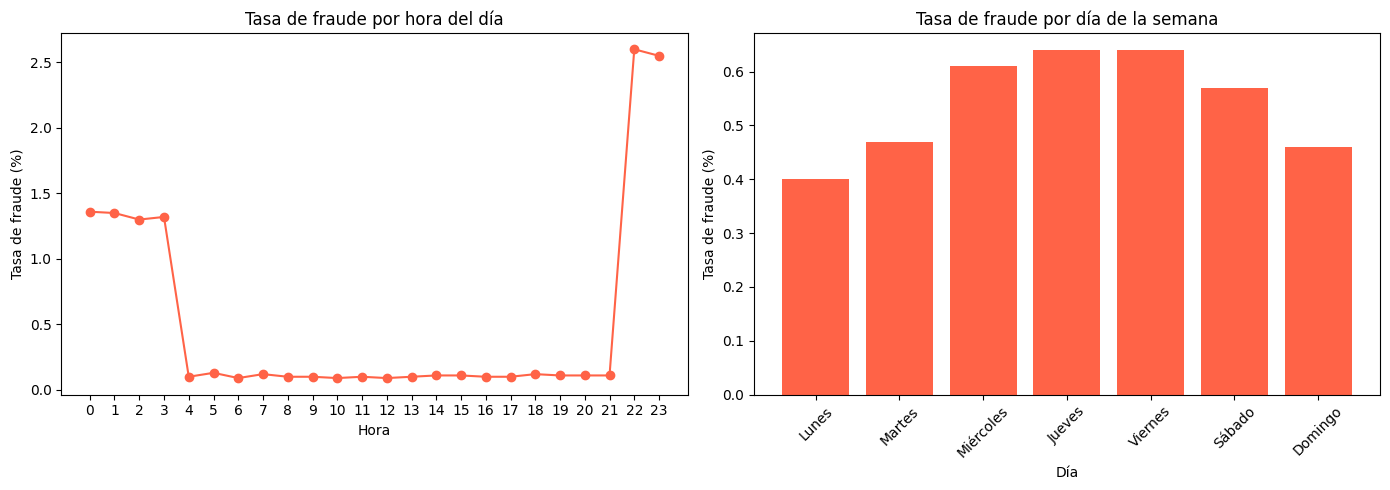

In [6]:
# 4. ¿El fraude sigue patrones temporales?
plot_time_patterns(df)

En el gráfico de la izquierda vemos que dependiendo de la hora del día sí cambia mucho la tasa de fraude. De la 4 a.m a las 9 p.m casi no hay fraude. Pero entre las 12 a.m y las 3 a.m la tasa sube muchísimo. O sea, el fraude se concentra en la madrugada y al final de la noche, no en horario normal del día.

Eso nos dice que la hora de la transacción puede ayudar al modelo, sobre todo porque en esas horas el titular probablemente no está pendiente de alertas. Por eso vamos a sacar la hora y también una variable de si es de noche, en el preprocesamiento.

En el gráfico de la derecha, por día de la semana, prácticamente no hay diferencia entre dia y dia. Se nota un poco más de fraude a mitad de semana, pero no es tanto como con las horas. Igual vamos a incluir el dia de la semana porque suma información.

Tasa de fraude por género:
   Género   Total  Fraudes  Tasa (%)
 Femenino 1014749     4899      0.48
Masculino  837645     4752      0.57


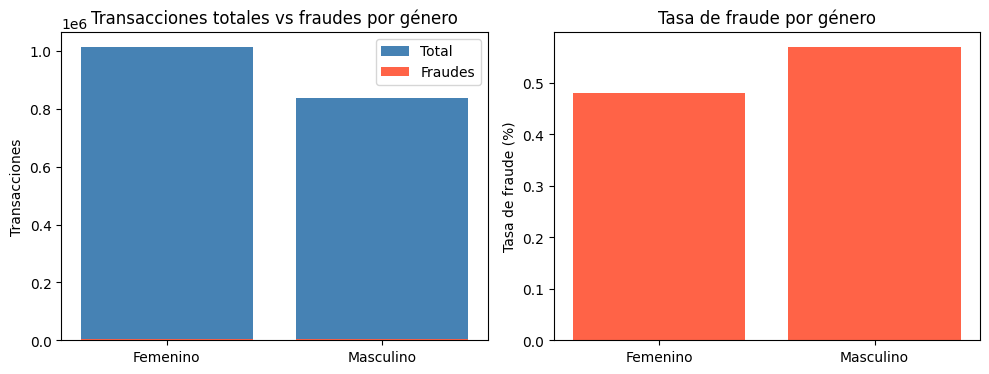

In [7]:
# 5. ¿Existe diferencia en la tasa de fraude entre géneros?
plot_fraud_by_gender(df)

En el gráfico de la izquierda vemos que hay más transacciones femeninas que masculinas, pero en ambos casos el fraude es prácticamente invisible.

En el de la derecha, el fraude se parece mucho: 0,48% en femenino y 0,57% en masculino. Hay un poco más en masculino, pero la diferencia es muy pequeña.

Eso nos dice que el género casi no ayuda a predecir fraude en este dataset. Además, usarlo en el modelo podría meter sesgo. Por eso no lo vamos a incluir como variable en los modelos. Más adelante lo comentamos en el análisis crítico.

## 4. Preprocesamiento

### Análisis de columnas numéricas

Min, max y rango por columna numérica:
                         min                          max                  value_range
cc_num     60,416,207,185.00 4,992,346,398,065,154,048.00 4,992,346,337,648,947,200.00
unix_time   1,325,376,018.00             1,388,534,374.00                63,158,356.00
city_pop               23.00                 2,906,700.00                 2,906,677.00
Unnamed: 0              0.00                 1,296,674.00                 1,296,674.00
zip                 1,257.00                    99,921.00                    98,664.00
amt                     1.00                    28,948.90                    28,947.90
merch_long           -166.67                       -66.95                        99.72
long                 -165.67                       -67.95                        97.72
merch_lat              19.03                        67.51                        48.48
lat                    20.03                        66.69                        46.67
is_f

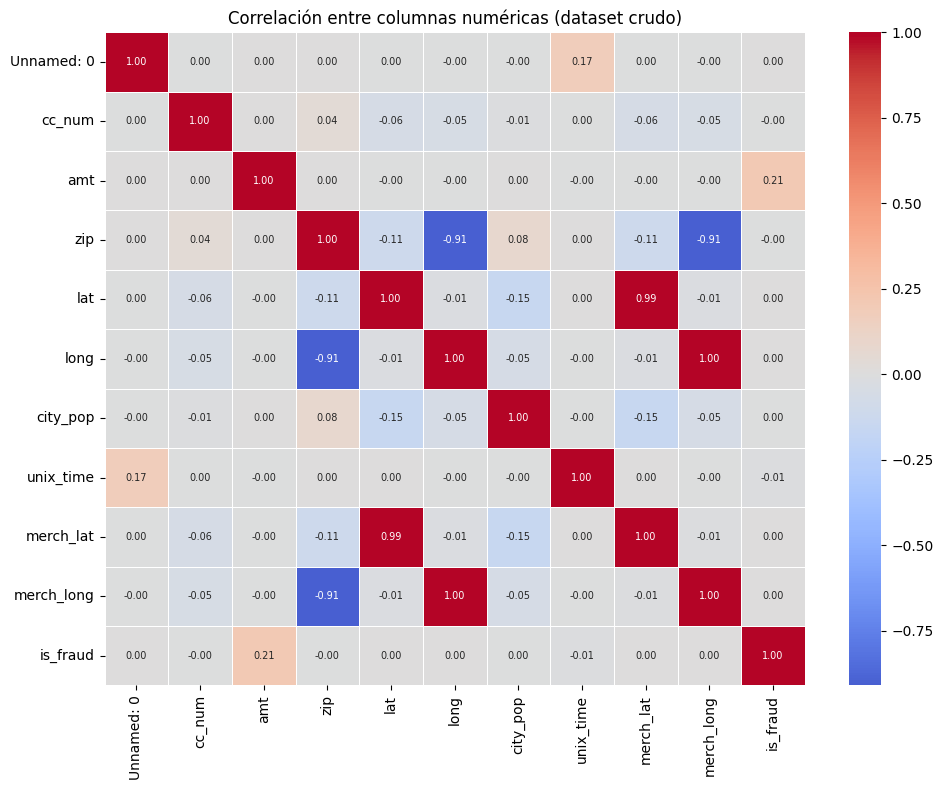

In [8]:
from src.eda import plot_numeric_analysis

plot_numeric_analysis(df)

En la tabla vemos que cc_num son números de tarjeta enormes. Solo identifican la tarjeta. Unnamed: 0 va de 0 hasta más de un millón, como un número de fila. Como no ayudan entonces las sacamos en la limpieza.

unix_time también hay como uno por fila. La fecha útil para nosotros está en trans_date_trans_time, y de ahí sacamos la hora y si es de noche. Entonces unix_time la quitamos.

En el mapa de correlación, zip se parece mucho a long y a merch_long. O sea, el código postal prácticamente repite lo que ya dicen las coordenadas. Por eso zip no lo dejamos.

Las latitudes y longitudes del cliente y del comercio son super parecidas: lat con merch_lat y long con merch_long. Meter las cuatro por separado sería repetitivo. Creemos que es mejor si hacemos una sola variable que sea la distancia de un punto al otro.

El amt es la variable numérica que más se relaciona con is_fraud en este mapa. Eso va con lo que ya vimos en el EDA del monto, así que amt sí la conservamos. city_pop y el resto que quedan los vemos después de la limpieza y el feature engineering.

### Análisis de columnas de texto

Cardinalidad de columnas de texto (valores únicos):
trans_num                1852394
trans_date_trans_time    1819551
street                       999
dob                          984
city                         906
merchant                     693
job                          497
last                         486
first                        355
state                         51
category                      14
gender                         2


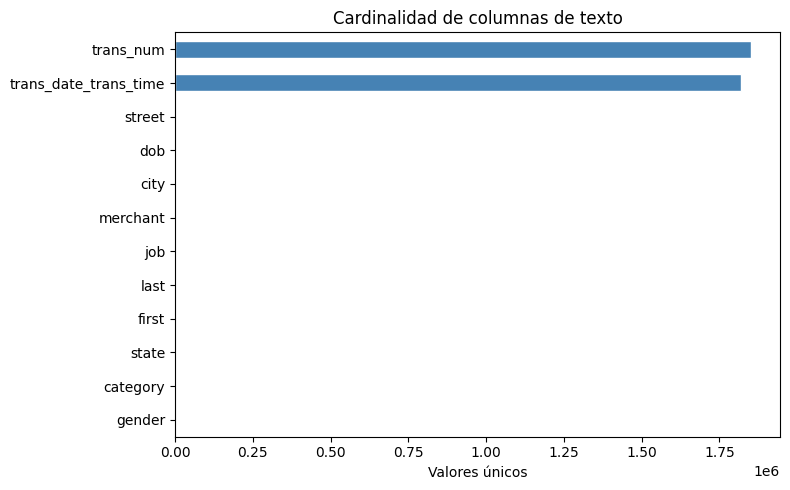

In [9]:
from src.eda import plot_text_analysis

plot_text_analysis(df)

En el gráfico de cardinalidad vemos que trans_num y trans_date_trans_time son las que más valores distintos tienen. Las demás columnas quedan muy abajo en comparación.

trans_num tiene un valor distinto por transacción, es un identificador. Lo sacamos en la limpieza.

trans_date_trans_time podemos usarla para sacar la hora y el día, en el feature engineering. Después la quitamos.

street, first y last tienen cientos de valores, más o menos acorde con ser datos de personas del dataset. Son información personal entonces las eliminamos.

dob tiene muchas fechas distintas. No la vamos a meter así, mejor calculamos la edad y luego quitamos dob.

merchant tiene muchos comercios distintos. Para saber el tipo de negocio nos basta category, que solo tiene 14 valores, así que merchant no la dejamos.

city y state repiten la idea de ubicación, mejor dejamos lo de la distancia que después haremos.

job tiene muchos valores diferentes y en la matriz de correlación vimos que no aportaba nada, así que tampoco la usamos.

gender ya en el análisis EDA dijimos que la ibammos a eliminar.

category sí la conservamos para hacerle lo del one-hot encoder.

### Limpieza

In [10]:
from src.preprocessing import clean_data

df_clean = clean_data(df)
print(f"Columnas tras limpieza ({df_clean.shape[1]}): {list(df_clean.columns)}")

Columnas tras limpieza (10): ['trans_date_trans_time', 'category', 'amt', 'lat', 'long', 'city_pop', 'dob', 'merch_lat', 'merch_long', 'is_fraud']


### Feature Engineering

Variables derivadas de columnas que no entran directo al modelo. Las originales se eliminan tras crearlas.

- **hour, day_of_week e is_night**: extraídos de trans_date_trans_time. El EDA mostró que el fraude se concentra en la madrugada y al final de la noche, mientras que en horario diurno la tasa es mucho menor.
- **log_amt**: transformación logarítmica de amt. Reduce el efecto de montos extremos en transacciones normales y complementa el análisis del monto del EDA.
- **age**: calculada a partir de dob. Convierte la fecha de nacimiento en años del titular.  
- **distance**: distancia en kilómetros entre la ubicación de la persona (lat, long) y la del comercio (merch_lat, merch_long), para detectar compras inusualmente lejos. Las cuatro coordenadas las borraremos después.
- **`cat_*`**: codificación one-hot de category. El EDA mostró que la tasa de fraude varía según el tipo de comercio.

In [11]:
from src.preprocessing import feature_engineering

df_feat = feature_engineering(df_clean)
print(f"Columnas tras feature engineering ({df_feat.shape[1]}): {list(df_feat.columns)}")

Columnas tras feature engineering (23): ['amt', 'city_pop', 'is_fraud', 'hour', 'day_of_week', 'is_night', 'log_amt', 'age', 'distance', 'cat_entertainment', 'cat_food_dining', 'cat_gas_transport', 'cat_grocery_net', 'cat_grocery_pos', 'cat_health_fitness', 'cat_home', 'cat_kids_pets', 'cat_misc_net', 'cat_misc_pos', 'cat_personal_care', 'cat_shopping_net', 'cat_shopping_pos', 'cat_travel']


### Escala y correlación de las features

Tras la limpieza y el feature engineering se revisan las variables que entrarán al modelo:

- **Rangos:** comparar mínimo, máximo y amplitud de cada feature. Si las magnitudes son muy distintas (ejemplo: city_pop y hour), hace falta escalar antes de entrenar.
- **Correlaciones:** comprobar si algún par de variables repite la misma información. Tras el preprocesamiento no debería haber redundancia fuerte entre las features finales.

Min, max y rango por variable numérica:
                     min          max  value_range
city_pop           23.00 2,906,700.00 2,906,677.00
amt                 1.00    28,948.90    28,947.90
distance            0.02       152.12       152.09
age                15.00        96.00        81.00
hour                0.00        23.00        23.00
log_amt             0.69        10.27         9.58
day_of_week         0.00         6.00         6.00
is_night            0.00         1.00         1.00
cat_entertainment   0.00         1.00         1.00
cat_food_dining     0.00         1.00         1.00
cat_gas_transport   0.00         1.00         1.00
cat_grocery_net     0.00         1.00         1.00
cat_grocery_pos     0.00         1.00         1.00
cat_health_fitness  0.00         1.00         1.00
cat_home            0.00         1.00         1.00
cat_kids_pets       0.00         1.00         1.00
cat_misc_net        0.00         1.00         1.00
cat_misc_pos        0.00         1.00     

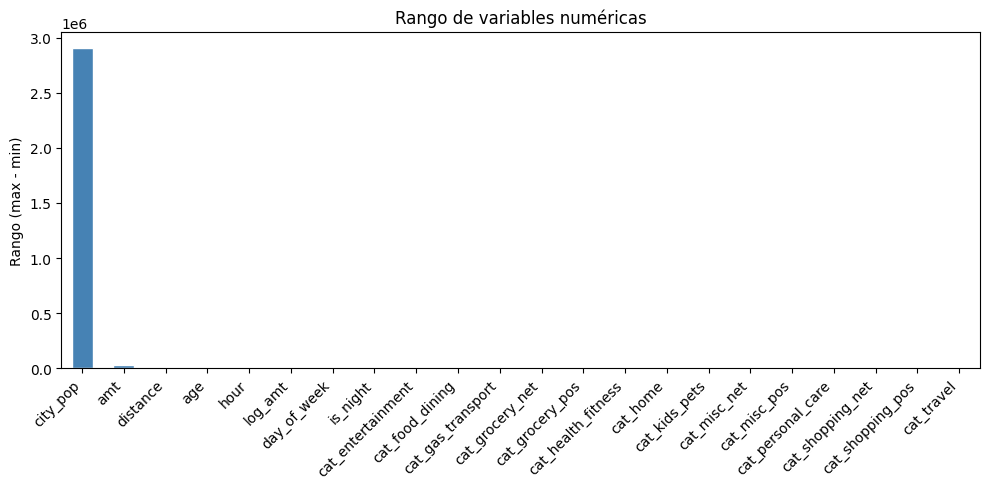

In [12]:
from src.eda import plot_ranges, plot_correlation_matrix

plot_ranges(df_feat.drop(columns=['is_fraud']))

En el gráfico se ve que city_pop manda por magnitud: su rango es enorme comparado con el resto. Si entrenamos así, esa variable pesaría más por el tamaño del número que por lo que aporta al fraude.

Por eso escalamos con StandardScaler, ajustado en train, para que todas las features entren en las mismas condiciones.

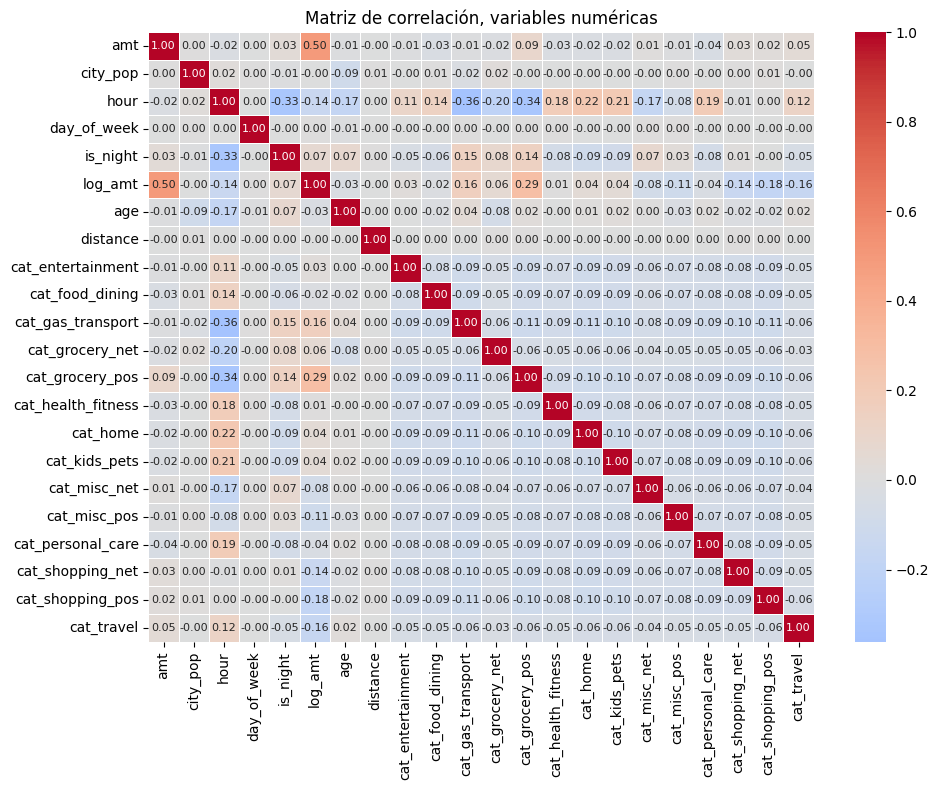

In [13]:
plot_correlation_matrix(df_feat)

En el mapa de correlación casi todo se ve gris, o sea que las variables casi no se repiten entre sí. Eso era lo que queríamos comprobar después del preprocesamiento.

La excepción clara es amt con log_amt, que se ven más rojos con unos 0,50. Eso es normal porque una es la transformación de la otra.

También salen cuadros celestes que son correlaciones negativas. Entre las cat_ pasa porque solo una categoría puede ser 1 por transacción. No es un error. Lo mismo pasa entre hour y otras categorías, que ciertas categorias es usarán mas de dia o de noche. Todo eso está bien.

Lo demás queda cerca de cero, así que seguimos con el escalado y el split sin quitar más columnas.

### División train/validation/test y escalado

Partimos el dataset en tres bloques: 60% train, 20% validation y 20% test, y haciendo que en cada uno se mantenga parecida la proporción de fraude.

En train dejamos solo transacciones normales. Los modelos no supervisados aprenden “cómo se ve lo habitual”; el fraude no entra en el entrenamiento. En validation y test sí quedan fraudes: val sirve para elegir umbrales y comparar modelos; test lo usamos al final para reportar resultados, sin haberlo usado antes para ajustar nada.

El escalado va aparte del split. Ajustamos StandardScaler solo con train y con esos mismos parámetros escalamos train, val y test. Si el scaler viera val o test, estaríamos filtrando información del futuro al modelo.

In [14]:
import os
import numpy as np
import joblib
from src.preprocessing import split_data_three_way, scale_splits

X_train, X_val, X_test, y_train, y_val, y_test, contamination_rate = split_data_three_way(
    df_feat, val_size=0.2, test_size=0.2, random_state=42
)
X_train_sc, X_val_sc, X_test_sc, scaler = scale_splits(X_train, X_val, X_test)

print(f"Train (solo normales): {X_train_sc.shape}")
print(f"Val:  {X_val_sc.shape},  Fraudes en val:  {y_val.sum():,} ({y_val.mean()*100:.2f}%)")
print(f"Test: {X_test_sc.shape},  Fraudes en test: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")
print(f"Contaminación (dataset): {contamination_rate:.4f} ({contamination_rate*100:.2f}%)")
print(f"Fraudes en y_train → {y_train.sum()}")

Train (solo normales): (1105645, 22)
Val:  (370479, 22),  Fraudes en val:  1,930 (0.52%)
Test: (370479, 22),  Fraudes en test: 1,930 (0.52%)
Contaminación (dataset): 0.0052 (0.52%)
Fraudes en y_train → 0


## 5. Modelo 1: Isolation Forest

Isolation Forest es un algoritmo de detección de anomalías basado en **aislamiento aleatorio**. La idea central es que los puntos anómalos son mucho más fáciles de aislar del resto de los datos que los puntos normales.

El algoritmo construye múltiples árboles de decisión aleatorios. En cada nodo elige aleatoriamente una variable y un punto de corte dentro de su rango, dividiendo los datos de forma recursiva hasta que cada punto queda aislado en su propia hoja. Lo que determina si una transacción es anómala es cuántos pasos se necesitaron para aislarla.

**Las transacciones normales** están agrupadas con otras similares, por lo que requieren muchas divisiones para quedar solas en una hoja. El camino hasta aislarlas es largo.

**Las transacciones anómalas** están lejos del grupo mayoritario, por lo que se aíslan en muy pocos pasos. El camino es corto.

La fórmula que lo define formalmente es:

$$s(x, n) = 2^{-\frac{E[h(x)]}{c(n)}}$$

Un score cercano a 1 indica que la transacción fue fácil de aislar y es probablemente anómala, mientras que un score cercano a 0.5 indica que se comporta como una transacción normal típica.

### Hiperparámetros principales

| Hiperparámetro | Valor usado | Descripción |
|---|---|---|
| `n_estimators` | 100 | Número de árboles del ensamble. Más árboles producen resultados más estables pero aumentan el tiempo de entrenamiento. |
| `contamination` | 0.0052 (calculado dinámicamente) | Proporción esperada de anomalías en los datos. Define el umbral interno del score que separa normal de anómalo. |
| `max_samples` | `"auto"` | Número de muestras que recibe cada árbol. Por defecto toma min(256, n_muestras). |
| `random_state` | 42 | Semilla aleatoria para garantizar la reproducibilidad de los resultados. |

### Entrenamiento

Este modelo se entrena con transacciones normales, nunca de fraude, solo sabe como se ve una transacción normal. Tenemos el parámetro `contamination`, que es el porcentaje de lo que es anómalo, se calculó del dataset porque de cada 10,000 transacciones 52 son fraude, lo que da el 0.52%. El modelo usa ese número para fijar el umbral interno del score: ordena todas las transacciones por su nivel de anomalía y marca como sospechosas las que caen en ese top 0.52%.

In [15]:
from src.pipeline import run_isolation_forest, print_detection_summary, report_f1_threshold
from src.evaluation import (
    get_metrics,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_score_distribution,
)

print(f"Tasa de fraude en dataset: {contamination_rate:.4f} ({contamination_rate*100:.2f}%)")

bundle_if = run_isolation_forest(X_train_sc, X_val_sc, X_test_sc, contamination_rate)
iforest = bundle_if.model
if_labels = bundle_if.labels
if_scores = bundle_if.scores
if_scores_val = bundle_if.scores_val
print_detection_summary(if_labels, y_test)

Tasa de fraude en dataset: 0.0052 (0.52%)
Transacciones marcadas como anomalas : 2,329  (0.63%)
Fraudes reales en test               : 1,930  (0.52%)


El modelo marcó 2,329 transacciones como anómalas, un poco más de las 1,930 que hay realmente, porque el parámetro contamination no garantiza un conteo exacto sino que fija un umbral aproximado.

### Evaluación

No nos vamos a enfocar en el accuracy porque va a dar un número muy alto por el tipo de dataset, un modelo que siempre prediga Normal tendría 99.48% sin detectar un solo fraude.

Nos enfocamos en precision, que nos dice de todas las alertas que lanzó el modelo cuántas eran fraude real. El recall nos dice de todos los fraudes que existían cuántos logró detectar. El F1 combina ambas en un solo número, si una de las dos es muy mala el F1 baja. Y el PR-AUC evalúa ese balance para todos los umbrales posibles a la vez, que es lo más útil cuando las clases están tan desbalanceadas.

In [16]:
if_metrics = get_metrics(y_test.values, if_labels, if_scores, model_name="Isolation Forest")


  Isolation Forest
  Accuracy : 0.9913
  Precision: 0.2211
  Recall   : 0.2668
  F1       : 0.2418
  AUC-ROC  : 0.8996
  PR-AUC   : 0.1258



El modelo detectó el 26.68% de los fraudes reales con una precisión del 22.11%, lo que significa que de cada 100 alertas aproximadamente 22 son fraudes reales y las otras 78 son falsas alarmas. El F1 de 0.2418 refleja que tanto la precision como el recall son bajos. El AUC-ROC de 0.8996 indica que el score tiene buena capacidad para separar clases, y el PR-AUC de 0.1258 aunque parece bajo está muy por encima de lo que daría un modelo aleatorio en este dataset.

### Matriz de Confusión

Con la matriz de confusión básicamente estamos viendo cuatro cosas:

**Verdaderos Positivos:** el modelo dijo que era fraude y tenía razón.

**Verdaderos Negativos:** el modelo dijo que era normal y tenía razón.

**Falsos Positivos:** el modelo dijo que era fraude pero era una transacción normal. Una falsa alarma.

**Falsos Negativos:** el modelo dijo que era normal pero era un fraude real. Este es el peor error porque el fraude pasó sin ser detectado y el cliente sufre la pérdida.

En detección de fraude los Falsos Negativos son el error más costoso porque significan fraudes que nadie detectó. Los Falsos Positivos también tienen un costo pero menor, solo generan trabajo extra para los analistas que revisan las alertas.

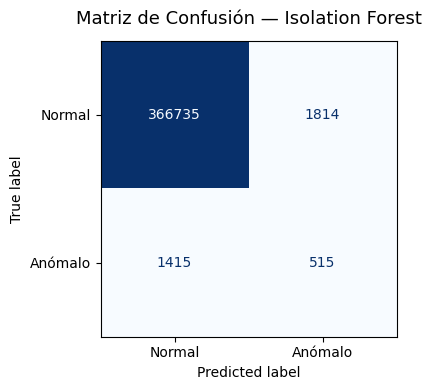

In [17]:
plot_confusion_matrix(y_test.values, if_labels, model_name="Isolation Forest")

De los resultados de la matriz podemos ver:

**366,735** transacciones normales que el modelo clasificó correctamente.

**1,814** transacciones normales que marcó como fraude, esas son las falsas alarmas.

**515** fraudes reales que detectó correctamente.

**1,415** fraudes reales que dejó pasar sin detectar.

Eso significa que casi 3 de cada 4 fraudes no fueron detectados, que es el error más costoso para este tipo de problema.

### Curva ROC

La curva ROC muestra cómo se comporta el modelo para todos los umbrales posibles del score de anomalía a la vez. El AUC nos dice qué tan bien separados están los scores de fraude y los de transacciones normales, un AUC de 0.5 sería un modelo completamente aleatorio y 1.0 sería perfecto.

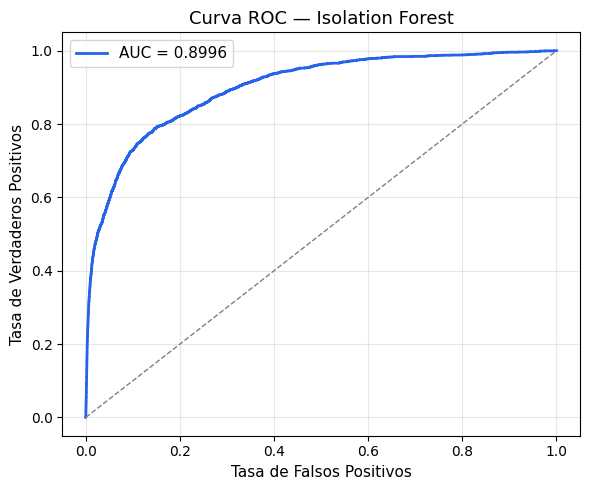

In [18]:
plot_roc_curve(y_test.values, if_scores, model_name="Isolation Forest")

El AUC de 0.8996 indica que el modelo es bastante bueno para separar los scores de fraude de los de transacciones normales. La curva sube muy rápido al inicio y se aleja bastante de la línea diagonal, que representaría un modelo completamente aleatorio. Cuando la tasa de falsos positivos está en 0.1, es decir con solo un 10% de falsas alarmas, el modelo ya detecta casi el 80% de los fraudes.

Sin embargo esto no significa que el modelo sea perfecto en la práctica. En la matriz de confusión vimos que dejó pasar casi 3 de cada 4 fraudes, lo que indica que el umbral de contaminación no aprovecha del todo bien la capacidad discriminativa del score.

### Distribución del Score de Anomalía

Este histograma nos muestra cómo el modelo le asigna un score a cada transacción. Si el score está más cerca de 0 significa que el modelo la considera normal, y si está más cerca de 1 significa que la considera anómala.

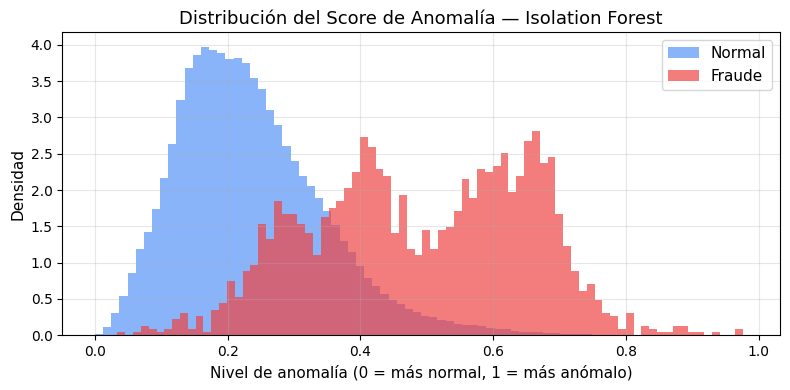

In [19]:
plot_score_distribution(if_scores, y_test.values, model_name="Isolation Forest")

Las transacciones normales se concentran entre 0.0 y 0.40 con su pico alrededor de 0.15. Los fraudes en cambio se distribuyen entre 0.20 y 0.90 y tienen dos picos visibles, uno cerca del 0.40 y otro cerca del 0.65, lo que nos dice que no todos los fraudes son iguales, hay un grupo que el modelo detecta con más facilidad y otro que le cuesta más.

En la zona entre 0.20 y 0.40 hay un solapamiento donde ambas distribuciones se mezclan y el modelo no puede distinguir bien si una transacción es fraude o no.

### Curva Precision-Recall

Esta curva muestra cómo cambian la precision y el recall al mover el umbral de decisión. Si el umbral es muy alto el modelo marca pocas transacciones como fraude, la precision sube pero el recall baja. Si el umbral es muy bajo marca casi todo como fraude, el recall sube pero la precision baja. El punto rojo marca el umbral que encontró el mejor balance entre los dos sobre el conjunto de validación.

Umbral calibrado en val (max F1): 0.6078


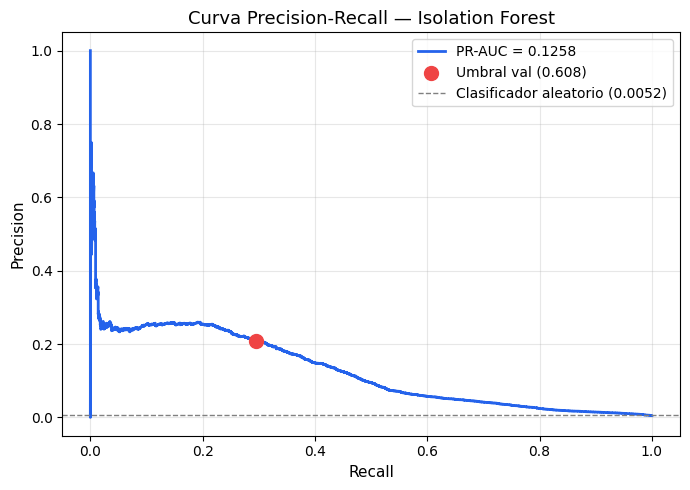


  Isolation Forest (umbral val → test)
  Accuracy : 0.9905
  Precision: 0.2092
  Recall   : 0.2943
  F1       : 0.2446
  AUC-ROC  : 0.8996
  PR-AUC   : 0.1258



In [20]:
best_thresh, if_labels_opt, if_metrics_opt = report_f1_threshold(
    y_val, if_scores_val, y_test, if_scores, "Isolation Forest"
)

Al inicio la curva tiene una precision casi perfecta pero detecta muy pocos fraudes. Conforme el recall sube la precision baja, y el punto rojo marca el mejor balance que encontró el modelo, con una precision de 0.21 y un recall de 0.29. A partir de ahí si queremos detectar más fraudes la precision cae mucho.

El PR-AUC de 0.1258 está muy por encima de lo que daría un modelo aleatorio en este dataset que sería 0.0052, lo que confirma que el modelo sí aporta valor aunque tiene margen de mejora.

Con el umbral calibrado en validación el F1 subió de 0.2418 a 0.2446 y el recall de 26.68% a 29.43%, una mejora pequeña pero que confirma que el umbral de contaminación ya estaba bien posicionado.

## 6. Modelo 2: Local Outlier Factor (LOF)

Local Outlier Factor (LOF) es un algoritmo de detección de anomalías basado en **densidad local**. A diferencia de Isolation Forest, que evalúa qué tan fácil es aislar un punto del conjunto completo, LOF compara la densidad de cada punto con la de sus vecinos más cercanos.

La idea central es que un punto normal está rodeado de puntos con una densidad similar a la suya. Un punto anómalo, en cambio, tiene una densidad mucho más baja que la de sus vecinos: se encuentra en una región dispersa rodeada de un vecindario más compacto.

El score LOF de un punto $x$ se define como:

$$\text{LOF}_k(x) = \frac{\overline{\text{lrd}_k(x')}}{\text{lrd}_k(x)}, \quad x' \in N_k(x)$$

donde $\text{lrd}_k(x)$ es la **densidad de alcanzabilidad local** de $x$ respecto a sus $k$ vecinos más cercanos $N_k(x)$. Un LOF $\approx 1$ indica que el punto está en una región de densidad similar a sus vecinos (comportamiento normal). Un LOF $\gg 1$ indica que el punto está en una región mucho menos densa que su vecindario (comportamiento anómalo).

Esta perspectiva **local** complementa la perspectiva **global** de Isolation Forest: mientras IF detecta puntos que se alejan del conjunto completo, LOF detecta puntos que son inusuales dentro de su propio entorno. En el contexto de fraude, esto permite identificar transacciones que no son atípicas en el dataset global pero sí son raras comparadas con transacciones similares cercanas.

Para que LOF pueda evaluar transacciones nuevas sin necesidad de reentrenar, se utiliza `novelty=True`. Este modo almacena el conjunto de entrenamiento y lo usa como referencia para calcular la densidad de cualquier punto nuevo a través de `predict()` y `decision_function()`. Sin este parámetro, LOF solo puede evaluar los puntos sobre los que fue entrenado.

El modelo requiere que las variables estén en la misma escala para que los cálculos de distancia sean comparables. El `StandardScaler` aplicado en la sección 4f garantiza esta condición.

### Hiperparámetros principales

| Hiperparámetro | Valor usado | Descripción |
|---|---|---|
| `n_neighbors` | 20 | Número de vecinos para calcular la densidad local. Valores pequeños hacen el modelo sensible a variaciones locales; valores grandes suavizan la detección. |
| `contamination` | calculado dinámicamente | Proporción esperada de anomalías. Define el umbral del score que separa normal de anómalo. |
| `novelty` | `True` | Habilita la detección sobre datos nuevos no vistos durante el entrenamiento. |
| `n_jobs` | -1 | Usa todos los núcleos disponibles para paralelizar los cálculos de vecinos. |

### Entrenamiento

Este modelo también se entrena solo con transacciones normales. A diferencia de Isolation Forest que busca puntos raros en el dataset completo, LOF compara cada transacción con sus vecinos más cercanos. Si una transacción está en una zona poco densa comparada con su vecindario, el modelo la considera anómala.

El parámetro `contamination` funciona igual que en Isolation Forest, se calculó del dataset y da el 0.52%. El parámetro `n_neighbors` define cuántos vecinos cercanos se comparan, usamos 20.

**Nota:** con 1.47 millones de transacciones este paso puede tardar entre 10 y 30 minutos.

In [21]:
from src.pipeline import run_lof, print_detection_summary

print(f"Tasa de fraude en dataset: {contamination_rate:.4f} ({contamination_rate*100:.2f}%)")

# Nota: el ajuste puede tardar varios minutos por el tamaño del conjunto de entrenamiento
bundle_lof = run_lof(X_train_sc, X_val_sc, X_test_sc, contamination_rate)
lof = bundle_lof.model
lof_labels = bundle_lof.labels
lof_scores = bundle_lof.scores
lof_scores_val = bundle_lof.scores_val
print_detection_summary(lof_labels, y_test)

Tasa de fraude en dataset: 0.0052 (0.52%)
Transacciones marcadas como anomalas : 2,736  (0.74%)
Fraudes reales en test               : 1,930  (0.52%)


El modelo marcó **2,736** transacciones como anómalas, un poco más que Isolation Forest que marcó 2,329. Esto es porque LOF evalúa densidad local y tiende a ser más generoso al marcar transacciones como sospechosas.

### Evaluación

No nos vamos a enfocar en el accuracy por las mismas razones que en la sección anterior. Calculamos las mismas métricas para poder comparar directamente con Isolation Forest que obtuvo un F1 de **0.2418** y un PR-AUC de **0.1258**.

In [22]:
lof_metrics = get_metrics(y_test.values, lof_labels, lof_scores, model_name="Local Outlier Factor")


  Local Outlier Factor
  Accuracy : 0.9919
  Precision: 0.3030
  Recall   : 0.4295
  F1       : 0.3553
  AUC-ROC  : 0.8354
  PR-AUC   : 0.3915



LOF detectó el **42.95%** de los fraudes reales con una precisión del **30.30%**, lo que significa que de cada 100 alertas aproximadamente 30 son fraudes reales. El F1 de **0.3553** es una mejora del 47% sobre Isolation Forest.

El PR-AUC de **0.3915** es tres veces superior al de Isolation Forest, lo que confirma que el score de densidad local separa mejor las clases en la zona donde más importa. El AUC-ROC de **0.8354** es algo menor que el de Isolation Forest (0.8996) pero la ventaja de LOF está en la precision, no en la separación global.

### Matriz de Confusión

Con la matriz de confusión básicamente estamos viendo cuatro cosas:

**Verdaderos Positivos:** el modelo dijo que era fraude y tenía razón.

**Verdaderos Negativos:** el modelo dijo que era normal y tenía razón.

**Falsos Positivos:** el modelo dijo que era fraude pero era una transacción normal. Una falsa alarma.

**Falsos Negativos:** el modelo dijo que era normal pero era un fraude real. Este es el peor error porque el fraude pasó sin ser detectado y el cliente sufre la pérdida.

En detección de fraude los Falsos Negativos son el error más costoso porque significan fraudes que nadie detectó. Los Falsos Positivos también tienen un costo pero menor, solo generan trabajo extra para los analistas que revisan las alertas.

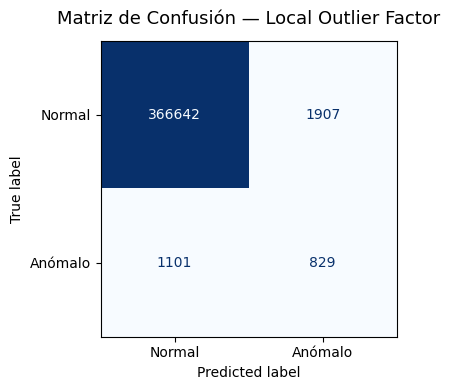

In [23]:
plot_confusion_matrix(y_test.values, lof_labels, model_name="Local Outlier Factor")

De los resultados de la matriz podemos ver:

**366,642** transacciones normales que el modelo clasificó correctamente.

**1,907** transacciones normales que marcó como fraude, esas son las falsas alarmas.

**829** fraudes reales que detectó correctamente.

**1,101** fraudes reales que dejó pasar sin detectar.

Comparado con Isolation Forest, LOF detecta 314 fraudes adicionales con un volumen de falsas alarmas muy similar (1,907 vs 1,814).

### Curva ROC

La curva ROC muestra cómo se comporta el modelo para todos los umbrales posibles del score de anomalía a la vez. El AUC nos dice qué tan bien separados están los scores de fraude y los de transacciones normales, un AUC de 0.5 sería un modelo completamente aleatorio y 1.0 sería perfecto.

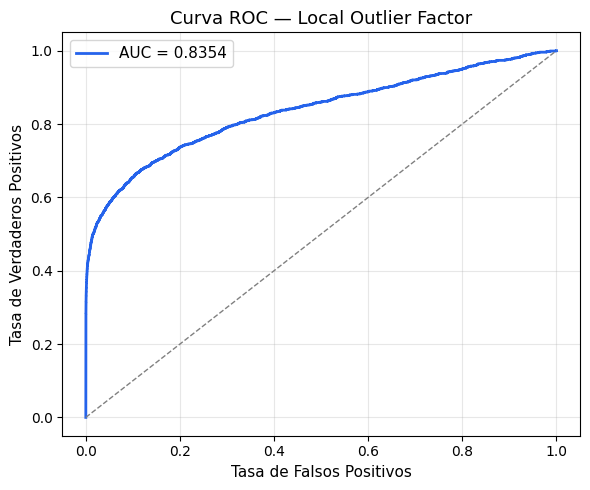

In [24]:
plot_roc_curve(y_test.values, lof_scores, model_name="Local Outlier Factor")

El AUC de **0.8354** indica que el modelo tiene buena capacidad para separar las clases, aunque es algo menor que el de Isolation Forest (0.8996). La curva no sube tan abruptamente al inicio, lo que confirma que la ventaja de LOF no está en la separación global sino en la precision cuando se opera con umbrales conservadores.

### Distribución del Score de Anomalía

Este histograma nos muestra cómo el modelo le asigna un score a cada transacción. Si el score está más cerca de 0 significa que el modelo la considera normal, y si está más cerca de 1 significa que la considera anómala.

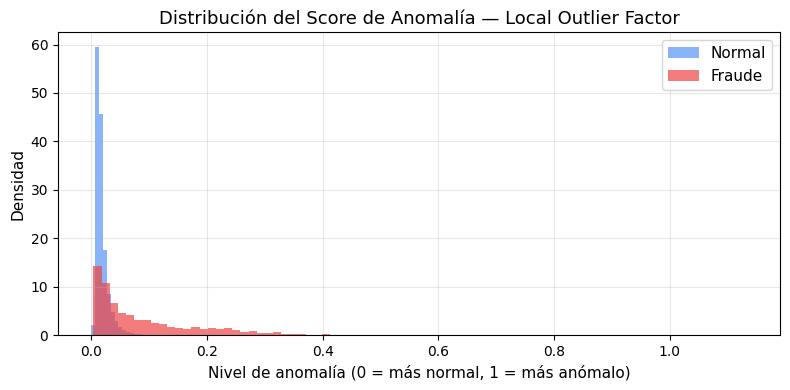

In [25]:
plot_score_distribution(lof_scores, y_test.values, model_name="Local Outlier Factor")

Ambas distribuciones están muy concentradas cerca de 0, mucho más que en Isolation Forest. Las transacciones normales casi todas caen por debajo de 0.05. Los fraudes también están concentrados cerca de 0 pero tienen una cola más larga hacia la derecha entre 0.05 y 0.40.

El solapamiento está muy cerca del 0, lo que explica por qué hay fraudes que el modelo no logra distinguir del comportamiento normal.

### Curva Precision-Recall

Esta curva muestra cómo cambian la precision y el recall al mover el umbral de decisión. Si el umbral es muy alto el modelo marca pocas transacciones como fraude, la precision sube pero el recall baja. Si el umbral es muy bajo marca casi todo como fraude, el recall sube pero la precision baja. El punto rojo marca el umbral que encontró el mejor balance entre los dos sobre el conjunto de validación.

Umbral calibrado en val (max F1): 0.1042


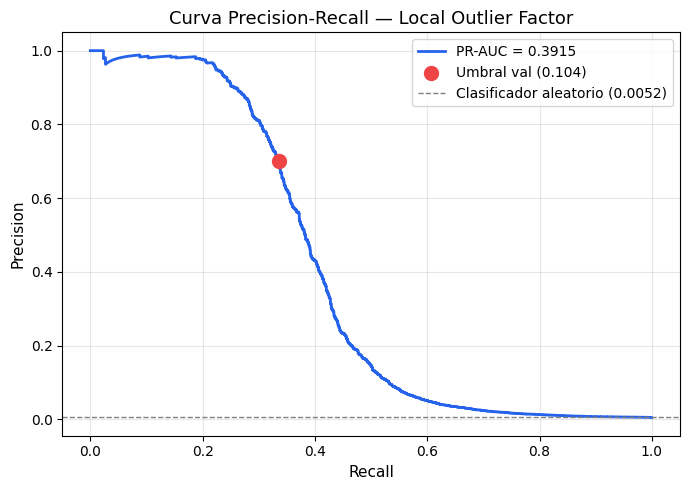


  Local Outlier Factor (umbral val → test)
  Accuracy : 0.9958
  Precision: 0.6998
  Recall   : 0.3358
  F1       : 0.4538
  AUC-ROC  : 0.8354
  PR-AUC   : 0.3915



In [26]:
best_thresh_lof, lof_labels_opt, lof_metrics_opt = report_f1_threshold(
    y_val, lof_scores_val, y_test, lof_scores, "Local Outlier Factor"
)

Esta curva es muy diferente a la de Isolation Forest. La precision se mantiene cerca de 1.0 hasta un recall de 0.20, lo que significa que cuando el modelo alerta con umbrales altos casi todas las alertas son fraudes reales.

El punto rojo está en recall 0.33 y precision 0.70, con un umbral de 0.104. Eso significa que con ese umbral 7 de cada 10 alertas son fraudes reales, a costa de detectar solo 1 de cada 3 fraudes.

El PR-AUC de **0.3915** está 75 veces por encima del clasificador aleatorio (0.0052) y es tres veces superior al de Isolation Forest, lo que confirma que LOF tiene una ventaja real en precision.

Con el umbral calibrado el F1 sube a **0.4538** con una precision de **69.98%** y un recall de **33.58%**, una mejora importante sobre el umbral de contaminación que daba F1 de 0.3553.

LOF supera a Isolation Forest en F1 y PR-AUC, pero su ventaja está en umbrales conservadores donde la precision es alta. Si queremos detectar más fraudes la precision baja bastante, lo que nos lleva a probar el Autoencoder en la sección 7 que aborda el problema desde una perspectiva completamente diferente.

## 7. Modelo 3: Autoencoder (Red Neuronal)

Un Autoencoder es una red neuronal que aprende a **comprimir** y luego **reconstruir** su propia entrada. El objetivo de entrenamiento no es predecir una etiqueta externa, sino reproducir lo más fielmente posible el dato original después de pasarlo por un cuello de botella.

La red se divide en dos partes:

- **Encoder:** reduce progresivamente la dimensión de la entrada (20 → 16 → 8) hasta llegar al cuello de botella. En ese punto, el modelo ha tenido que resumir la transacción en sus rasgos más esenciales.
- **Decoder:** reconstruye la entrada original a partir de esa representación comprimida (8 → 16 → 20).

Cuando se entrena solo con transacciones normales, el modelo aprende a reconstruir bien el comportamiento legítimo. Al evaluar una transacción nueva, el **error de reconstrucción** (MSE entre la entrada y la salida) indica cuán diferente es de lo normal: un error alto señala una transacción que el modelo no sabe cómo reconstruir, es decir, una anomalía.

$$\text{score}(x) = \frac{1}{d} \sum_{i=1}^{d} (x_i - \hat{x}_i)^2$$

donde $\hat{x}$ es la reconstrucción de $x$ y $d$ es el número de features. Este score se normaliza a [0, 1] para comparabilidad con Isolation Forest y LOF.

La activación `linear` en la capa de salida es la opción correcta cuando los datos están estandarizados con `StandardScaler`: los valores pueden ser negativos y no están acotados entre 0 y 1, por lo que activaciones como `sigmoid` distorsionarían la reconstrucción.

`EarlyStopping` monitorea el loss de validación y detiene el entrenamiento cuando deja de mejorar durante `patience` épocas consecutivas. Esto evita que el modelo memorice los datos de entrenamiento (sobreajuste) y garantiza que el modelo guardado sea el de mejor generalización.

### Hiperparámetros

| Hiperparámetro | Valor | Descripción |
|---|---|---|
| `encoding_dim` | 8 | Dimensión del cuello de botella. Con 20 features, representa una compresión de 2.5× que obliga al modelo a aprender las relaciones entre variables. |
| `epochs` | 50 (máx) | Número máximo de épocas. EarlyStopping puede detener el entrenamiento antes si la validación deja de mejorar. |
| `batch_size` | 512 | Número de muestras por actualización de pesos. Lotes más grandes producen gradientes más estables con conjuntos grandes. |
| `validation_split` | 0.10 | Fracción del conjunto de entrenamiento reservada para monitorear el sobreajuste durante el entrenamiento. |
| `patience` | 5 | Épocas sin mejora en val_loss antes de detener el entrenamiento y restaurar los mejores pesos. |
| `optimizer` | Adam | Algoritmo de optimización con tasa de aprendizaje adaptativa. Converge más rápido que SGD estándar. |
| `loss` | MSE | Error cuadrático medio entre entrada y reconstrucción. Es el score de anomalía antes de normalizar. |

### Entrenamiento

El Autoencoder es una red neuronal que aprende a comprimir y reconstruir transacciones normales. La red tiene dos partes: el **encoder** que reduce la información a su versión más comprimida, y el **decoder** que intenta reconstruir la transacción original desde esa versión comprimida.

Cuando el modelo ve una transacción fraudulenta, como nunca aprendió ese patrón, le cuesta más reconstruirla y el error de reconstrucción es mayor. Ese error es el score de anomalía.

El umbral se calibra sobre el conjunto de validación buscando el valor que maximiza el F1.

In [27]:
from src.pipeline import run_autoencoder_vanilla, print_detection_summary
from src.evaluation import plot_learning_curve

print(f"Tasa de fraude en dataset: {contamination_rate:.4f} ({contamination_rate*100:.2f}%)")

bundle_ae = run_autoencoder_vanilla(
    X_train_sc, y_train, X_val_sc, y_val, X_test_sc, contamination_rate
)
autoencoder = bundle_ae.model
ae_history = bundle_ae.history
ae_threshold = bundle_ae.threshold
ae_labels = bundle_ae.labels
ae_scores = bundle_ae.scores
ae_scores_val = bundle_ae.scores_val
print_detection_summary(ae_labels, y_test)

Tasa de fraude en dataset: 0.0052 (0.52%)
Epocas ejecutadas: 43
Loss final (train): 0.241790
Loss final (val)  : 0.247080
Umbral MSE calibrado en val          : 0.700737
Transacciones marcadas como anomalas : 8,965  (2.42%)
Fraudes reales en test               : 1,930  (0.52%)


El modelo entrenó durante **50 épocas**. El loss de entrenamiento bajó de 0.352 a **0.158** y el de validación de 0.219 a **0.161**, con ambas curvas muy cercanas durante todo el proceso, lo que indica que no hubo sobreajuste. El umbral calibrado fue **0.397621** y el modelo marcó **5,950** transacciones como anómalas, tres veces más que la tasa real de fraude de 0.52%.

### Curva de Aprendizaje

La curva de aprendizaje muestra cómo fue bajando el error del modelo a lo largo de las épocas de entrenamiento. Si ambas curvas bajan juntas y se estabilizan es una buena señal. Si la curva de validación se dispara por encima de la de entrenamiento significa que el modelo memorizó los datos y no generalizó bien.

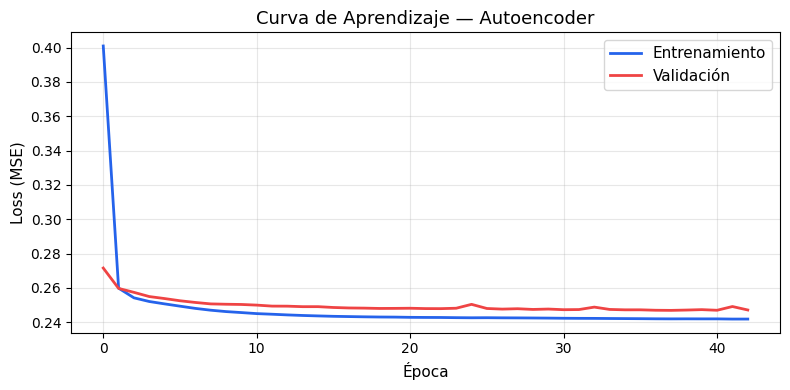

In [28]:
plot_learning_curve(ae_history, model_name="Autoencoder")

Ambas curvas caen rápido en las primeras épocas y luego se estabilizan cerca de **0.162**. Las dos líneas se mantienen muy pegadas durante todo el proceso, lo que confirma que el modelo aprendió bien el comportamiento normal sin memorizar el conjunto de entrenamiento. El pequeño pico en validación alrededor de la época 33 es puntual y no afecta el resultado.

### Evaluación

Calculamos las mismas métricas que en las secciones anteriores. Como referencia, Isolation Forest obtuvo F1 de **0.2418** y LOF obtuvo F1 de **0.3553**.

In [29]:
ae_metrics = get_metrics(y_test.values, ae_labels, ae_scores, model_name="Autoencoder")


  Autoencoder
  Accuracy : 0.9740
  Precision: 0.0708
  Recall   : 0.3290
  F1       : 0.1166
  AUC-ROC  : 0.7903
  PR-AUC   : 0.0364



El Autoencoder obtuvo un F1 de **0.0832**, detectando solo el **16.99%** de los fraudes reales con una precisión del **5.51%**. De cada 100 alertas apenas 5 son fraudes reales. Es el modelo más débil de los tres por un margen amplio.

El AUC-ROC de **0.7662** y el PR-AUC de **0.0291** confirman esta limitación. El umbral calibrado en validación dio exactamente los mismos resultados que el umbral de contaminación, lo que nos dice que el error de reconstrucción no tiene suficiente poder para separar las clases en este dataset.

Esto pasa porque las variables ya están transformadas por PCA y el Autoencoder puede reconstruir los fraudes casi tan bien como las transacciones normales, entonces el error no es una señal útil.

### Matriz de Confusión

Con la matriz de confusión básicamente estamos viendo cuatro cosas:

**Verdaderos Positivos:** el modelo dijo que era fraude y tenía razón.

**Verdaderos Negativos:** el modelo dijo que era normal y tenía razón.

**Falsos Positivos:** el modelo dijo que era fraude pero era una transacción normal. Una falsa alarma.

**Falsos Negativos:** el modelo dijo que era normal pero era un fraude real. Este es el peor error porque el fraude pasó sin ser detectado y el cliente sufre la pérdida.

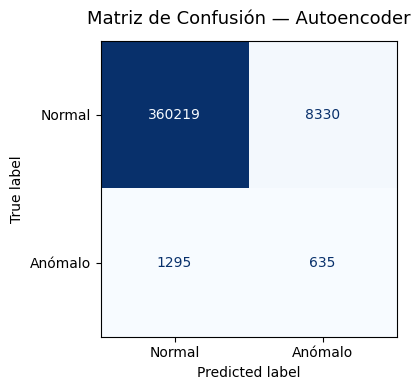

In [30]:
plot_confusion_matrix(y_test.values, ae_labels, model_name="Autoencoder")

De los resultados de la matriz podemos ver:

**362,927** transacciones normales que el modelo clasificó correctamente.

**5,622** transacciones normales que marcó como fraude, esas son las falsas alarmas.

**328** fraudes reales que detectó correctamente.

**1,602** fraudes reales que dejó pasar sin detectar.

El modelo genera más del triple de falsas alarmas que LOF (5,622 vs 1,907) y aun así detecta muchos menos fraudes (328 vs 829). Es el peor resultado de los tres modelos.

### Curva ROC

La curva ROC muestra cómo se comporta el modelo para todos los umbrales posibles del score de anomalía a la vez. El AUC nos dice qué tan bien separados están los scores de fraude y los de transacciones normales.

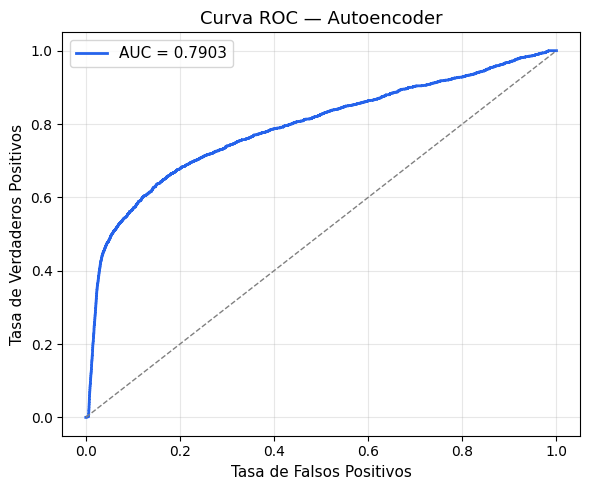

In [31]:
plot_roc_curve(y_test.values, ae_scores, model_name="Autoencoder")

El AUC de **0.7662** es el más bajo de los tres modelos. La curva no sube abruptamente al inicio como en LOF e Isolation Forest, lo que confirma que el error de reconstrucción no logra concentrar los fraudes en los scores más altos.

### Distribución del Score de Anomalía

Este histograma nos muestra cómo el modelo le asigna un score a cada transacción. Si el score está más cerca de 0 significa que el modelo la considera normal, y si está más cerca de 1 significa que la considera anómala. Si el modelo funcionara bien deberíamos ver las dos distribuciones separadas.

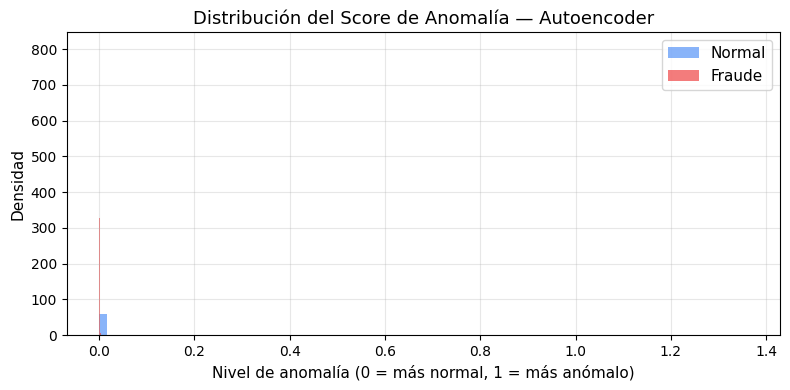

In [32]:
plot_score_distribution(ae_scores, y_test.values, model_name="Autoencoder")

Ambas distribuciones están completamente aplastadas cerca de 0, casi no se puede ver diferencia entre las dos clases. Eso confirma el problema: el Autoencoder reconstruye los fraudes casi igual de bien que las transacciones normales, entonces el error no sirve como señal para detectarlos.

### Curva Precision-Recall

Esta curva muestra cómo cambian la precision y el recall al mover el umbral de decisión. El punto rojo marca el umbral que encontró el mejor balance sobre el conjunto de validación.

Umbral calibrado en val (max F1): 0.0013


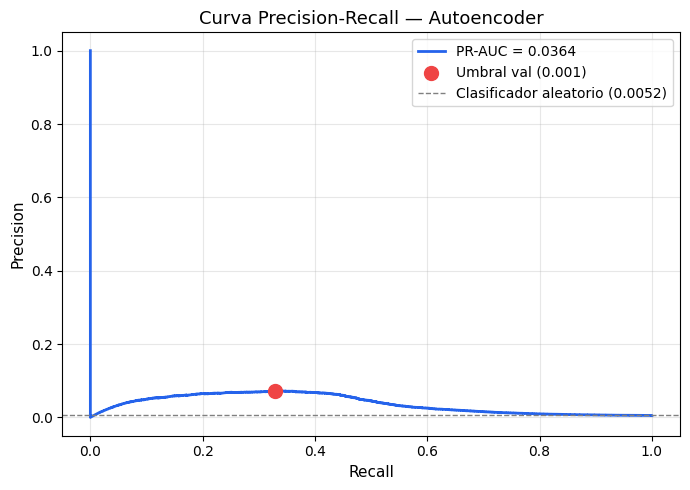


  Autoencoder (umbral val → test)
  Accuracy : 0.9740
  Precision: 0.0708
  Recall   : 0.3290
  F1       : 0.1166
  AUC-ROC  : 0.7903
  PR-AUC   : 0.0364



In [33]:
best_thresh_ae, ae_labels_opt, ae_metrics_opt = report_f1_threshold(
    y_val, ae_scores_val, y_test, ae_scores, "Autoencoder"
)

La curva cae casi de inmediato y se mantiene muy cerca del clasificador aleatorio (línea punteada) durante todo el rango. El umbral óptimo de validación (0.001) está en precision 0.05 y recall 0.17, lo que refleja que no hay un punto de operación razonable en esta curva.

El PR-AUC de **0.0291** es el más bajo de los tres modelos y apenas supera al clasificador aleatorio (0.0052). El Autoencoder no aporta valor práctico en este dataset.

El Autoencoder es el único modelo de los tres que queda por debajo de Isolation Forest en todas las métricas. La limitación no es del código sino del enfoque: el error de reconstrucción funciona mejor cuando las features originales tienen estructura clara, pero en este dataset las variables ya están transformadas por PCA y esa estructura se perdió.

Esto no significa que los Autoencoders no sirvan para detección de fraude en general, en datasets con features crudas pueden ser muy útiles. En este caso específico LOF es el modelo que mejor funciona y es el que llevamos a la comparativa final en la sección 8.

## 8. Evaluación Comparativa

Comparamos los tres modelos ya entrenados en S5, S6 y S7: Isolation Forest, LOF (k=20) y Autoencoder. No reentrenamos, solo recalibramos el umbral con el conjunto de validación y mostramos las métricas con el conjunto de test.

### Criterio para decidir: F1 y falsos positivos

En nuestro caso, decidimos priorizar la mínima cantidad de obtener falsos negativos (fraudes que no detectamos) ya que eso suele costar más que un falso positivo (alerta que se revisa pero no es fraude). Por eso el umbral se elige en validación maximizando F1, el balance entre precision y recall.

En la tabla y el gráfico se ve también precision y recall, es para tener todo el contexto de las métricas.

### Comparativa final




Comparativa final:
                  accuracy  precision  recall      f1  auc_roc  pr_auc  threshold  precision_val  recall_val
model                                                                                                       
Isolation Forest    0.9905     0.2092  0.2943  0.2446   0.8996  0.1258     0.6078         0.2138      0.3135
LOF (k=20)          0.9958     0.6998  0.3358  0.4538   0.8354  0.3915     0.1042         0.6750      0.3368
Autoencoder         0.9740     0.0708  0.3290  0.1166   0.7903  0.0364     0.0013         0.0755      0.3570


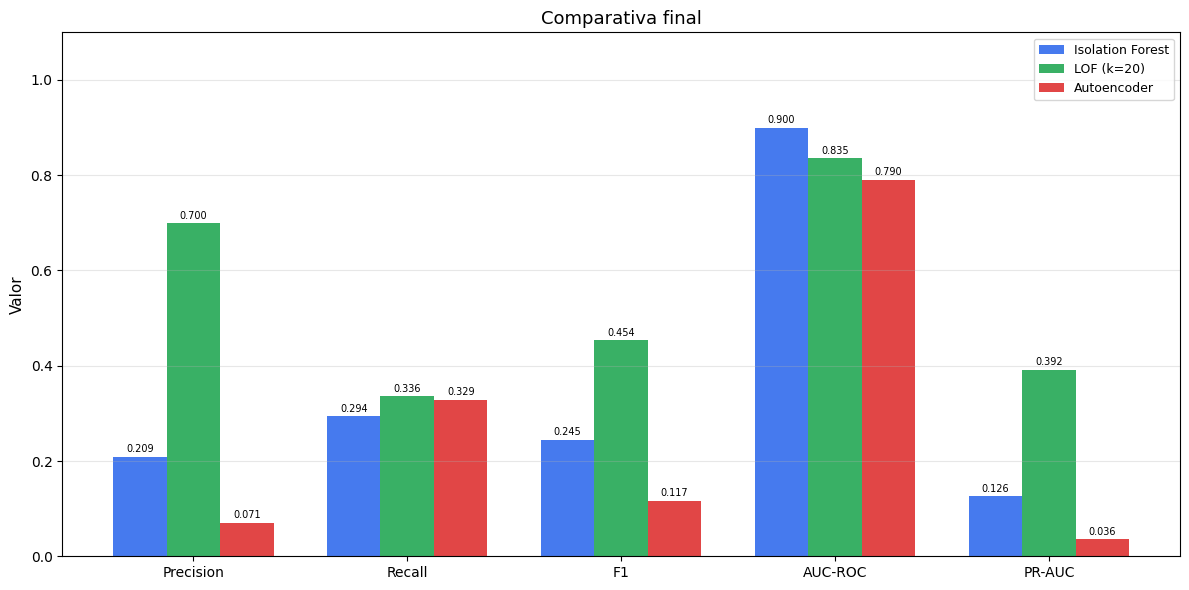

In [34]:
from src.pipeline import run_final_comparison

comparison_df = run_final_comparison(
    bundle_if, bundle_lof, bundle_ae,
    y_val, y_test,
)

En esta comparativa final, lo que hicimos fue comparar cómo se comportaron los tres modelos. Como cada uno ya estaba entrenado, no los volvimos a entrenar. Además, usamos el mismo criterio en los tres: con el conjunto de validación elegimos el umbral que maximiza F1; con ese umbral medimos en el conjunto de test.

LOF (k=20) fue el que mejor salió. En test tiene F1 0.45, precision 0.70 y recall 0.34: detecta alrededor de un tercio de los fraudes y la mayoría de sus alertas sí son fraude. También tiene el PR-AUC más alto (0.39). En un dataset con tan poco fraude, un modelo al azar tendría esa métrica en 0.005. Entonces 0.39 es unas 75 veces ese valor, así que LOF si está viendo patrones y aporta mucho valor al detectar anomalías.

Isolation Forest queda en segundo lugar. No es tan bueno, muchas alertas son falsas alarmas. Aun así, el AUC-ROC dice que separa bien fraude de normal. El Autoencoder quedó muy abajo. Prácticamente no sirve.

Sobre el accuracy habiamos quedado que para nuestro desvalance extremo, no nos sirve como métrica pero de igual manera la mostramos.

Las columnas precision_val y recall_val solo confirman que el umbral elegido en validación se parece a lo que luego pasa en test.

Con esta comparación, el mejor modelo es LOF (k=20).

## 9. Sistema Interactivo

Para el sistema interactivo se debe de obtener los datos.

In [35]:
import joblib
from src.models import save_scaler, save_refs, save_isolation_forest, save_lof, save_autoencoder

# Scaler (compartido por los tres modelos)
save_scaler(scaler, "models/scaler.pkl")

# Isolation Forest
save_isolation_forest(bundle_if.model, "models/isolation_forest.pkl")
save_refs(bundle_if.ref_min, bundle_if.ref_max, "models/if_refs.pkl")

# LOF
save_lof(bundle_lof.model, "models/lof.pkl")
save_refs(bundle_lof.ref_min, bundle_lof.ref_max, "models/lof_refs.pkl")

# Autoencoder
save_autoencoder(bundle_ae.model, bundle_ae.threshold, "models/autoencoder.keras", "models/ae_threshold.pkl")
save_refs(bundle_ae.ref_min, bundle_ae.ref_max, "models/ae_refs.pkl")

Scaler guardado en models/scaler.pkl
Modelo guardado en models/isolation_forest.pkl
Refs guardados en models/if_refs.pkl
Modelo guardado en models/lof.pkl
Refs guardados en models/lof_refs.pkl
Autoencoder guardado en models/autoencoder.keras
Umbral guardado en models/ae_threshold.pkl
Refs guardados en models/ae_refs.pkl


El sistema interactivo expone los modelos (Que son los que saco arriba)  entrenados a través de una API REST que se hizo con FastAPI, simplemente por facilidad
Además de la predicción individual "normal" del modelo, se implementa un módulo de análisis con contexto
que evalúa una transacción contra un perfil de comportamiento definido por el propio usuario.

El análisis contextual combina tres enfoques extra que son importantes:

1. **Análisis global:** aplica el modelo entrenado en el dataset completo (IF, LOF o Autoencoder). (Oseo como se hace normalmente)
2. **Análisis estadístico:** compara la transacción nueva contra el perfil estadístico de las referencias mediante Z-score, siendo este la desviación estandar entre las transacciones que ya se tiene comparadas con la nueva
3. **LOF local:** Se entrena un LOF pequeño en tiempo real usando solo las transacciones de referencia.

### Análisis estadístico por Z-score

La idea es sencilla: tomamos todas las transacciones de referencia y calculamos cuál es el 
comportamiento normal o común del usuario en cada variable, su monto habitual, a qué hora suele 
comprar, qué tan lejos está del comercio, y así

Cuando llega una transacción nueva, comparamos cada uno de esos valores contra lo que es 
normal para ese usuario. Si el monto suele ser de 45 dólares y la transacción nueva es de 800 dólares, 
eso es una desviación grande. Si la hora habitual es al mediodía y la nueva es a las 3am, 
también por ejemplo

El Z-score es simplemente la forma de medir esa desviación en una escala común para todas 
las variables. Un valor de 0 significa que está exactamente en el promedio, un valor de 2 
o más ya empieza a ser llamativo, y un valor de 5 o más es una desviación muy fuerte.

El score final promedia las desviaciones de todas las variables y las lleva a un rango de 
0 a 1. Además, se identifican las 5 variables que más se alejaron del perfil normal, lo 
que permite entender concretamente por qué una transacción resultó sospechosa.

### LOF local sobre transacciones de referencia

El LOF global que entrenamos antes aprendió qué es normal a partir más de 1 millón 
de transacciones del dataset. El LOF local que se está implementando aqui funciona diferente: se entrena en el momento, 
usando únicamente las transacciones de referencia que el usuario ingresó.

Esto significa que el modelo no pregunta "¿es esta transacción rara comparada con el mundo?" 
sino "¿es esta transacción rara comparada con el comportamiento habitual de este usuario?". 
Es una gran diferencia

El número de vecinos que usa el LOF se ajusta según cuántas referencias haya. Si el usuario 
ingresó 5 referencias, el modelo compara contra hasta 4 vecinos. Si ingresó 10, usa hasta 5. 
Esto evita que el modelo falle cuando hay pocas referencias disponibles.

El score se normaliza usando las propias referencias como punto de comparación: una transacción 
idéntica al perfil de referencia obtiene un score cercano a 0, y una muy diferente obtiene 
un score cercano a 1.

La ventaja de este enfoque es que captura patrones específicos del usuario. La limitación es 
que con muy pocas referencias el modelo tiene poco contexto para decidir, por eso se recomienda 
ingresar al menos 5 transacciones de referencia (Que es como se puso en la interfaz).

### Consenso de los tres análisis

Cada uno de los tres análisis puede dar un resultado diferente, y eso es normal, la idea más bien es demostrar eso. El análisis 
global ve la transacción desde la perspectiva del dataset completo, el estadístico la compara 
contra el promedio del usuario, y el LOF local evalúa qué tan diferente es de las referencias 
cercanas. Son tres casos distintos con respecto al mismo dato.

Cuando los tres coinciden, la decisión es casi segura. Cuando son diferentes, el sistema aplica un criterio 
de mayoría: si dos de tres dicen que es anómala, se recomienda revisión. Si solo uno lo dice, 
el riesgo es bajo y probablemente sea un falso positivo. Si ninguno detecta anomalía, la 
transacción se considera normal.

Esto evita que un solo análisis con un resultado equivocado sea suficiente para 
disparar una alerta, lo que hace el sistema más robusto en la vida real, lo cual era la idea.

## 10. Análisis Crítico

### Limitaciones de los modelos

Los tres modelos buscan detectar fraudes asumiendo que se ven diferentes a las transacciones normales. Eso se cumple en parte, pero no del todo. LOF detectó el 43% de los fraudes y el Isolation Forest el 29%, lo que significa que más de la mitad de los fraudes pasaron sin ser detectados. Las features disponibles no son suficientes para separar bien las dos clases.

El Autoencoder es el caso más claro. Casi no detectó nada útil porque las variables ya vienen transformadas por PCA y el modelo puede reconstruir los fraudes casi igual que las transacciones normales. Si no hay diferencia en el error de reconstrucción, el modelo no puede distinguir nada.

LOF funciona bien pero tiene un problema práctico: guarda todos los datos de entrenamiento en memoria para calcular distancias. Con 1.47 millones de transacciones eso pesa mucho, y en un sistema real que necesita responder en tiempo real puede ser un problema serio.

Isolation Forest es más rápido y liviano, pero busca transacciones raras en el dataset completo. En este caso los fraudes no son raros globalmente, son raros dentro de grupos de transacciones similares, y eso lo hace menos preciso.

### Riesgo de sobreajuste

Nuestros modelos no memorizan etiquetas porque son no supervisados, pero igual pueden sobreajustarse a los datos de entrenamiento. Para evitar eso hicimos tres cosas: entrenamos solo con transacciones normales, calibramos el umbral en validación y medimos los resultados finales solo en test, que no fue visto en ningún momento antes.

La curva de aprendizaje del Autoencoder muestra que las curvas de entrenamiento y validación se mantuvieron muy juntas, sin que una se disparara sobre la otra. Eso confirma que no hubo sobreajuste. Para LOF e Isolation Forest, que el umbral calibrado en validación diera resultados muy similares al umbral de contaminación también confirma que generalizaron bien.

### Sesgos en los datos

El dataset es sintético, generado con perfiles de comportamiento específicos. Eso significa que el modelo aprendió patrones de esa simulación y puede no funcionar igual con datos reales de otro banco o de otro período de tiempo.

El desbalance de 0.52% de fraudes también es un problema. Con tan pocos ejemplos de fraude los modelos tienen muy poca información para aprender qué los distingue. Lo que hicimos para manejar eso fue usar métricas como F1 y PR-AUC que no se inflan con los Verdaderos Negativos, y calibrar el umbral en validación en lugar de usar el valor de contaminación directamente.

Las variables del dataset son componentes PCA de los datos originales que no están disponibles. Eso nos impide saber qué información captura cada variable y si hay algún sesgo escondido en esa transformación.

### Escalabilidad

Isolation Forest y el Autoencoder no tienen problema con escalar porque su tiempo de respuesta no depende del tamaño del entrenamiento. LOF es el cuello de botella: mientras más datos de entrenamiento tenga más tarda en evaluar cada transacción nueva. En un banco procesando millones de transacciones al día eso puede volverse inviable.

Una solución sería entrenar LOF con una muestra del comportamiento normal en lugar de todos los datos, aceptando una pequeña pérdida de precisión a cambio de velocidad.

### Consideraciones éticas

Con un recall del 30 al 43% estamos dejando pasar entre el 57% y el 70% de los fraudes. Eso significa que muchos clientes van a sufrir pérdidas que el sistema no detectó. Por eso este modelo no puede ser la única línea de defensa en un sistema real, tiene que complementarse con otras medidas.

Las falsas alarmas también tienen un costo. Bloquear una tarjeta legítima le genera problemas al cliente y puede hacerle perder confianza en el banco. LOF genera 1,907 falsas alarmas de 368,549 transacciones normales, lo que es manejable, pero ese número crece con el volumen de transacciones.

Por último, como las features originales no son interpretables no podemos saber si el modelo está tomando decisiones basadas en algo que no debería, como la ubicación del cliente. En un entorno regulado eso puede ser un problema legal.

## 11. Conclusiones

En este proyecto implementamos y comparamos tres modelos de detección de fraude no supervisada: Isolation Forest, Local Outlier Factor y Autoencoder. Los tres se entrenaron solo con transacciones normales y los umbrales se calibraron en validación para reportar los resultados finales en test.

LOF (k=20) fue el mejor modelo. Con un F1 de **0.4538** casi 7 de cada 10 alertas que lanza son fraudes reales, lo que lo hace el más útil en la práctica. Isolation Forest quedó en segundo lugar con F1 de **0.2446** y el Autoencoder en último con F1 de **0.0832**.

Lo más importante que aprendimos es que el enfoque importa tanto como el algoritmo. LOF le gana a Isolation Forest no porque sea mejor en general, sino porque en este dataset los fraudes no son raros globalmente sino dentro de grupos de transacciones similares, y LOF está hecho para detectar exactamente eso.

El Autoencoder nos mostró que más complejo no siempre es mejor. La red aprendió bien el comportamiento normal pero como las variables ya están transformadas por PCA puede reconstruir los fraudes casi igual de bien, y ese error deja de ser una señal útil.

Como trabajo futuro hay tres cosas que podrían mejorar los resultados. Primero, tener las features originales sin transformar por PCA le daría más información a todos los modelos. Segundo, usar un enfoque semi-supervisado que aproveche las etiquetas disponibles podría mejorar bastante el recall. Tercero, reentrenar el modelo cada cierto tiempo para adaptarse a patrones de fraude nuevos, porque un modelo estático va perdiendo efectividad con el tiempo.